In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Create synthetic dataset
np.random.seed(42)
n_features = 75
data = np.random.randn(665, n_features) * 10 + 50  # 6 samples, 10 features

# Convert to DataFrame
df = pd.DataFrame(data, columns=[f'Feature_{i+1}' for i in range(n_features)])
# print(df)


In [8]:
df.head(2)

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,...,Feature_66,Feature_67,Feature_68,Feature_69,Feature_70,Feature_71,Feature_72,Feature_73,Feature_74,Feature_75
0,54.967142,48.617357,56.476885,65.230299,47.658466,47.658630,65.792128,57.674347,45.305256,55.425600,...,63.562400,49.279899,60.035329,53.616360,43.548802,53.613956,65.380366,49.641740,65.646437,23.802549
1,58.219025,50.870471,47.009926,50.917608,30.124311,47.803281,53.571126,64.778940,44.817298,41.915064,...,52.274599,63.071428,33.925168,51.846339,52.598828,57.818229,37.630493,36.795434,55.219416,52.969847


Why Use Covariance Instead of Correlation?
🔹 Covariance measures joint variability:

It tells us:

Positive covariance → when 
X increases, Y tends to increase.

Negative covariance → when 
X increases, Y tends to decrease.

Correlation is scaled covariance:
So, correlation is useful for interpreting relationships, but PCA uses the actual scale of variation, which is why covariance is preferred.

👉 However: if you want PCA to be scale-invariant, you standardize the data before PCA (z-score scaling) — then correlation and covariance PCA behave similarly.

### Step 1: Standardize the Data
Make each feature have:

Mean = 0

Standard deviation = 1

### Step 2: Compute the Covariance Matrix
For a dataset X with shape 
n×d (samples × features): 

This matrix is d×d (10×10 in your case)

Diagonal entries → variance of each feature (should be 1 after standardization)

Off-diagonal → how much two features change together

    Close to 1 → highly positively correlated

    Close to -1 → strongly negative

    Close to 0 → no linear relationship


### Step 3: Compute Eigenvalues and Eigenvectors
From the covariance matrix 

Σv=λv
Where:

v: eigenvector (a principal component direction)
λ: eigenvalue (amount of variance in that direction)


### Step 4: Sort by Eigenvalues
Sort eigenvalues 
𝜆1 ,𝜆2,… ,… in descending order

Each corresponds to one principal component
Larger eigenvalue = more variance captured


### Step 5: Select Top k Components (Explained Variance)
Compute:

Explained Variance Ratio = 𝜆𝑖 / ∑𝜆j 

Then:
Compute cumulative variance
Choose smallest k such that cumulative variance ≥ threshold (e.g., 90%)

| Step | What You Do         | Math                                     | Output                 |
| ---- | ------------------- | ---------------------------------------- | ---------------------- |
| 1    | Standardize data    | $Z = \frac{X - \mu}{\sigma}$             | Centered matrix        |
| 2    | Covariance matrix   | $\Sigma = \frac{1}{n-1} X^T X$           | 10×10 matrix           |
| 3    | Eigen decomposition | $\Sigma \mathbf{v} = \lambda \mathbf{v}$ | Eigenvalues/vectors    |
| 4    | Sort eigenvalues    | Descending $\lambda_i$                   | Variance order         |
| 5    | Pick top $k$        | Use cumulative variance                  | Principal directions   |
| 6    | Project             | $Z_{\text{PCA}} = X \cdot V_k$           | Reduced feature matrix |


In [9]:

# Step 1: Standardize the data
scaler = StandardScaler()
X_std = scaler.fit_transform(df)
# Convert back to DataFrame for readability
X_std_df = pd.DataFrame(X_std, columns=df.columns)
print(X_std_df.head(2))

   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
0   0.495889  -0.116569   0.601481   1.429596  -0.234914  -0.177677   
1   0.808221   0.121251  -0.339751   0.022029  -2.165078  -0.163831   

   Feature_7  Feature_8  Feature_9  Feature_10  ...  Feature_66  Feature_67  \
0   1.606840   0.792479  -0.428782    0.567416  ...    1.361592   -0.075555   
1   0.363181   1.500195  -0.476804   -0.883139  ...    0.231140    1.257009   

   Feature_68  Feature_69  Feature_70  Feature_71  Feature_72  Feature_73  \
0    1.011250    0.420590   -0.635464    0.344348    1.452066   -0.073762   
1   -1.581785    0.234938    0.271869    0.762337   -1.308545   -1.343435   

   Feature_74  Feature_75  
0    1.561571    -2.47894  
1    0.534628     0.34623  

[2 rows x 75 columns]


           Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
Feature_1      1.002      0.006      0.001      0.049     -0.004     -0.013   
Feature_2      0.006      1.002     -0.027     -0.015      0.010     -0.038   

           Feature_7  Feature_8  Feature_9  Feature_10  ...  Feature_66  \
Feature_1      0.076     -0.073     -0.032      -0.037  ...       -0.02   
Feature_2      0.072      0.035     -0.028       0.018  ...       -0.00   

           Feature_67  Feature_68  Feature_69  Feature_70  Feature_71  \
Feature_1       0.021      -0.011       0.012       0.025      -0.011   
Feature_2       0.033       0.015      -0.010       0.007       0.011   

           Feature_72  Feature_73  Feature_74  Feature_75  
Feature_1      -0.071       0.017      -0.014       0.040  
Feature_2      -0.015      -0.018      -0.031       0.012  

[2 rows x 75 columns]


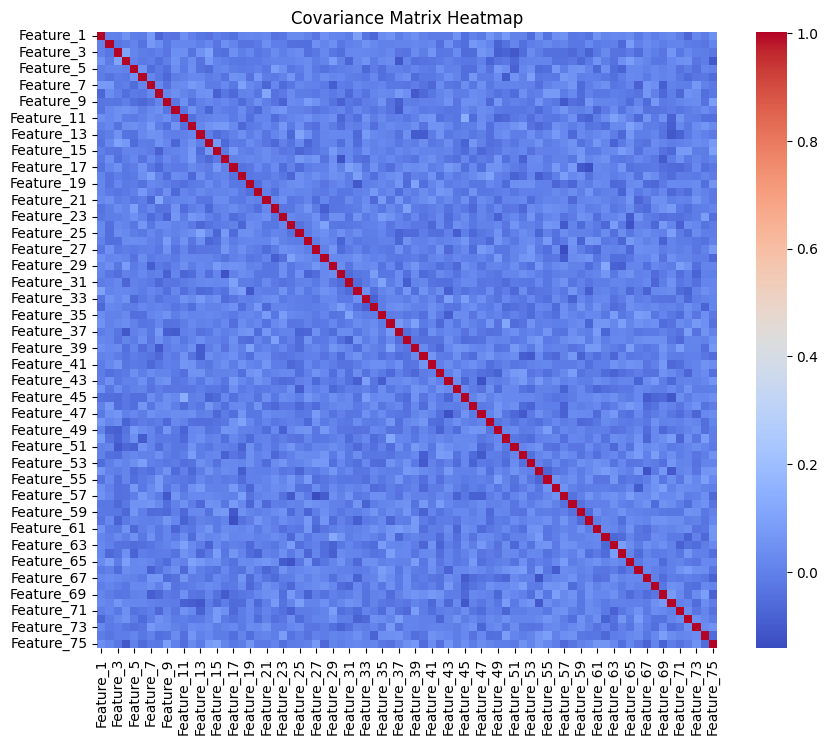

In [11]:
# Step 2: Compute the covariance matrix manually
n_samples = X_std.shape[0]
cov_matrix = (X_std.T @ X_std) / (n_samples - 1)

# Convert to DataFrame for readability
cov_df = pd.DataFrame(cov_matrix, index=df.columns, columns=df.columns).round(3)
print(cov_df.head(2))

plt.figure(figsize=(10, 8))
sns.heatmap(cov_df, cmap="coolwarm") #annot=True,  fmt=".2f",
plt.title("Covariance Matrix Heatmap")
plt.show()

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(cov_df)
# Sort eigenvalues and eigenvectors in descending order
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_idx]
eigenvectors_sorted = eigenvectors[:, sorted_idx]

In [27]:
# Create a DataFrame to view results clearly
eig_df = pd.DataFrame({
    'Eigenvalue': eigenvalues_sorted,
    'Explained Variance Ratio': eigenvalues_sorted / np.sum(eigenvalues_sorted)
})
cumulative_variance = np.cumsum(eigenvalues_sorted / np.sum(eigenvalues_sorted))

eig_df['cumulative_variance'] = cumulative_variance
eig_df = eig_df.round(4)
print(eig_df.head(2))

### What we have now
# Eigenvalues represent the variance explained by each principal component.
# Eigenvectors (columns) are the directions of the new PCA axes.
# We sort them so the most important components come first.



   Eigenvalue  Explained Variance Ratio  cumulative_variance
0      1.7109                    0.0228               0.0228
1      1.6853                    0.0224               0.0452


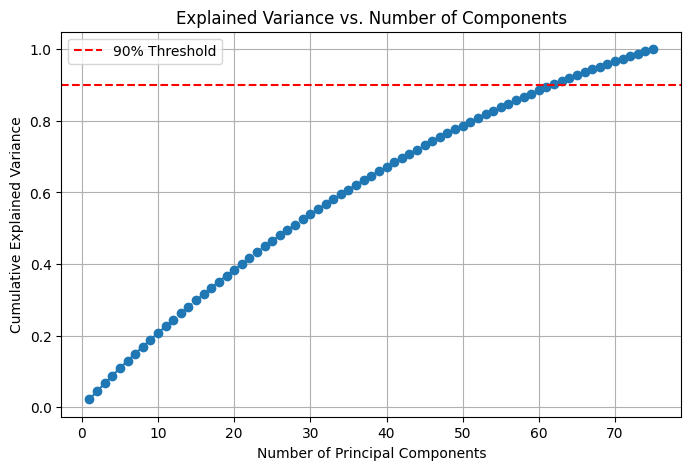

In [28]:
# Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Step 5: Project the data onto the top 2 principal components
top_k_eigenvectors = eigenvectors_sorted[:, :2]  # take first 2 eigenvectors
X_pca_2d = X_std @ top_k_eigenvectors  
#  X_std.shape, top_k_eigenvectors.shape ---> ((665, 75) , (75, 2)) ---> (665, 2)

# Convert to DataFrame
X_pca_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
print(X_pca_df)


          PC1       PC2
0    2.045537  0.817285
1   -0.163567 -1.230781
2   -0.773011  1.675024
3    2.351573 -2.204095
4   -1.676173  0.172661
..        ...       ...
660 -3.371871  3.238471
661  0.479913 -1.308563
662  1.146151  1.629042
663 -0.027238 -0.821649
664 -0.037850  0.155914

[665 rows x 2 columns]


In [33]:
top_k_eigenvectors.shape, X_std.shape

((75, 2), (665, 75))